In [17]:
#%matplotlib widget
import pandas as pd
import requests
import matplotlib.pyplot as plt
#from matplotlib.widgets import Slider
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
import numpy as np
import datetime
from datetime import date, timedelta
from dotenv import load_dotenv
from itertools import islice
import os
load_dotenv()  # загружаются переменные из файла
DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

In [18]:
#response1 = requests.get('https://data-charts-api.hexlet.app/visits?begin=2023-03-01&end=2023-09-01')
response1 = requests.get(f'{API_URL}/visits', params={'begin': DATE_BEGIN, 'end': DATE_END})
if response1.status_code == 200:
#    print(response1.json())
    df1 = pd.DataFrame(response1.json())
    df1['date'] = pd.to_datetime(df1['datetime']).dt.date
    df1['datetime'] = pd.to_datetime(df1['datetime'])
    df1_sor = df1.sort_values(by='datetime')
    df1_last = df1_sor.drop_duplicates(subset='visit_id', keep='last')
    res1 = df1_last.groupby(['date', 'platform']).agg({'visit_id': ['count']}).reset_index()
    res1.columns = ['date_group', 'platform','visits']
    print(res1.head())
#    print(df1.dtypes)
#    df1_last.to_csv('test_vis_220526v1.csv')

   date_group platform  visits
0  2023-03-01  android      75
1  2023-03-01      ios      22
2  2023-03-01      web     279
3  2023-03-02  android      67
4  2023-03-02      ios      31


In [19]:
#response2 = requests.get('https://data-charts-api.hexlet.app/registrations?begin=2023-03-01&end=2023-09-01')
response2 = requests.get(f'{API_URL}/registrations', params={'begin': DATE_BEGIN, 'end': DATE_END})
if response2.status_code == 200:
#    print(response1.json())
    df2 = pd.DataFrame(response2.json())
    df2['date'] = pd.to_datetime(df2['datetime']).dt.date
    res2 = df2.groupby(['date', 'platform']).agg({'user_id': ['count']}).reset_index()
    res2.columns = ['date_group', 'platform','registrations']
    print(res2.head())
#    res2.to_csv('test_regis220526v2.csv')

   date_group platform  registrations
0  2023-03-01  android             61
1  2023-03-01      ios             18
2  2023-03-01      web              8
3  2023-03-02  android             59
4  2023-03-02      ios             24


In [20]:
res3 = pd.merge(
    res1, res2,
    on = ['date_group', 'platform'],
    how='left'
)
res3['visits'] = res3['visits'].astype('Int64')
res3['registrations'] = res3['registrations'].astype('Int64')
res3['conversion'] = ((res3['registrations'] / res3['visits']) * 100)
res3 = res3[res3['platform'].isin(['android', 'ios','web'])]
res3['conversion'] = res3['conversion'].astype('Int64')
res3.to_json('./conversion.json')
print(res3.head())
res3.to_csv('conversions_platformv1.csv')
#res3.info()

   date_group platform  visits  registrations  conversion
0  2023-03-01  android      75             61          81
1  2023-03-01      ios      22             18          81
2  2023-03-01      web     279              8           2
3  2023-03-02  android      67             59          88
4  2023-03-02      ios      31             24          77


In [21]:
df_ads = pd.read_csv('ads.csv')
#print(df_regs.head())
df_ads['date_group'] = pd.to_datetime(df_ads['date']).dt.date
res4 = df_ads.groupby(['date_group', 'utm_campaign']).agg({'cost': ['sum']}).reset_index()
res4.columns = ['date_group', 'utm_campaign','cost']
print(res4.head())
#print(res4.dtypes)

   date_group                utm_campaign  cost
0  2023-03-01  advanced_algorithms_series   212
1  2023-03-02  advanced_algorithms_series   252
2  2023-03-03  advanced_algorithms_series   202
3  2023-03-04  advanced_algorithms_series   223
4  2023-03-05  advanced_algorithms_series   265


In [22]:
# шаг 4 собираем ads.json (по новому группируем итоговый conversion )
df_no_platf = res3.groupby('date_group').agg(
visits=('visits', 'sum'),
registrations=('registrations', 'sum')
).reset_index()
res5 = df_no_platf
print(df_no_platf.head())

   date_group  visits  registrations
0  2023-03-01     376             87
1  2023-03-02     613            106
2  2023-03-03     683            107
3  2023-03-04     647            159
4  2023-03-05     707            115


In [23]:
# join по date_group 
df_join = pd.merge(
    df_no_platf,res4,
    on = ['date_group'],
    how='left'
)
df_join['cost'] = df_join['cost'].fillna(0)
df_join = df_join[['date_group', 'visits', 'registrations','cost','utm_campaign']] 
df_join.to_json('./ads.json')
res6 = df_join
print(df_join.head())
#df_join.to_csv('test_ads_260526v1.csv')

   date_group  visits  registrations   cost                utm_campaign
0  2023-03-01     376             87  212.0  advanced_algorithms_series
1  2023-03-02     613            106  252.0  advanced_algorithms_series
2  2023-03-03     683            107  202.0  advanced_algorithms_series
3  2023-03-04     647            159  223.0  advanced_algorithms_series
4  2023-03-05     707            115  265.0  advanced_algorithms_series


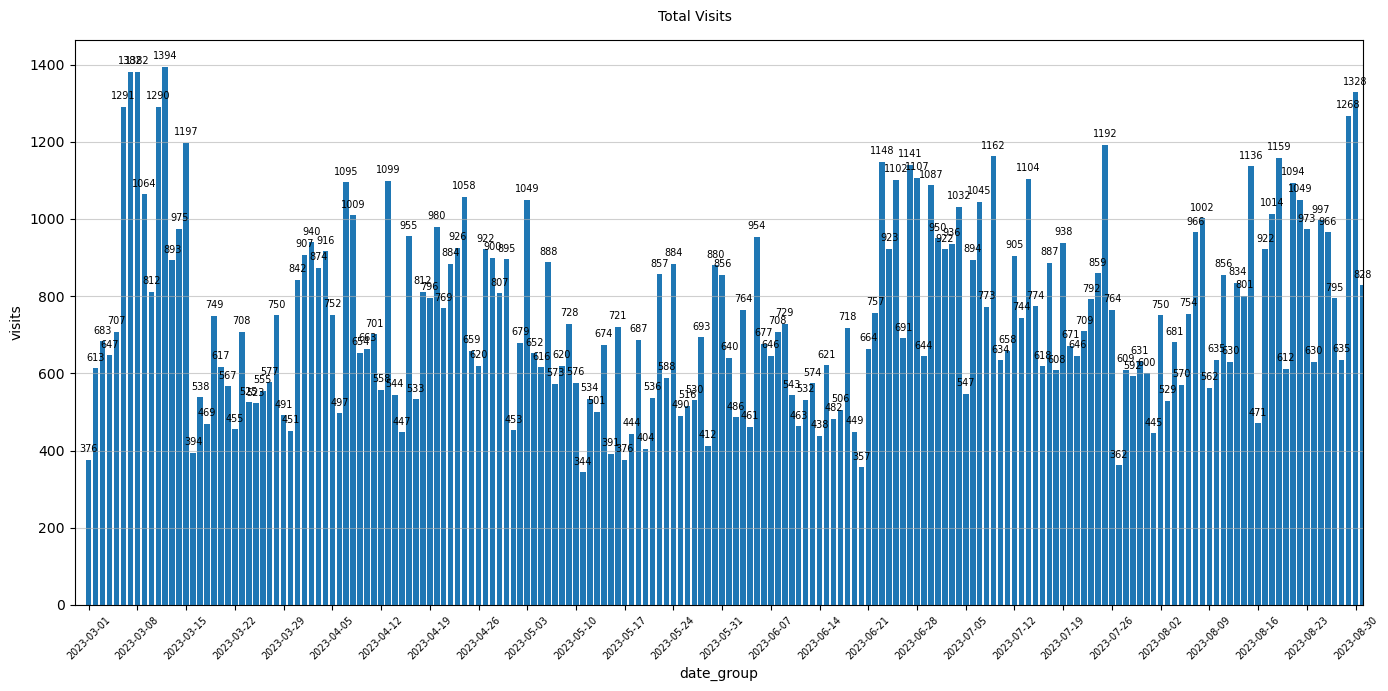

In [24]:
# первый график total_visits
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Total Visits",fontsize=10)
bars = ax.bar(res5['date_group'], res5['visits'])
# 3. Настройки отображения
total_days = len(res5['date_group'])
ax.bar_label(bars, padding=4, fontsize=7)
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_ylabel("visits")
#ax.xaxis.set_major_locator(MultipleLocator(7))
ax.set_xlim(res5['date_group'].iloc[0]-timedelta(days=2), res5['date_group'].iloc[total_days-1])
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
plt.tight_layout()
plt.savefig('./charts/total_visits.png')
plt.show()
plt.close()

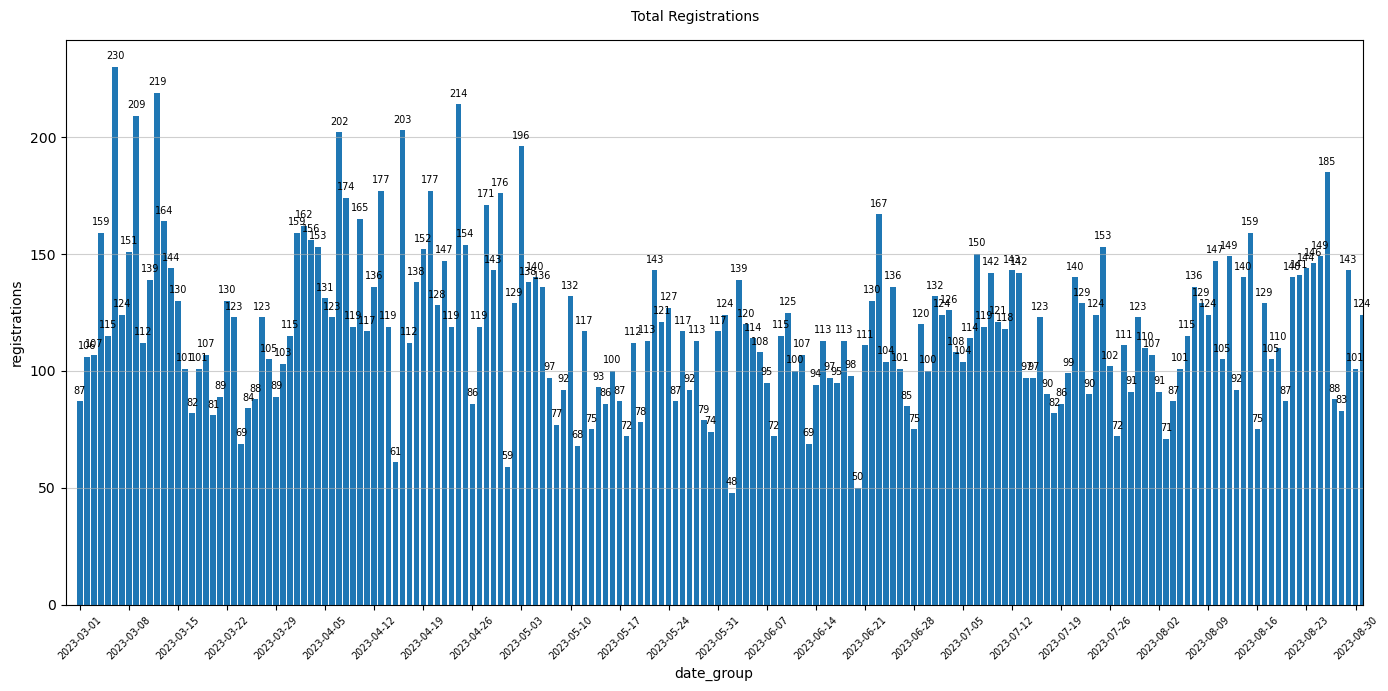

In [25]:
#  график total_registrations
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Total Registrations",fontsize=10)
bars = ax.bar(res5['date_group'], res5['registrations'])
# 3. Настройки отображения
total_days = len(res5['date_group'])
ax.bar_label(bars, padding=4, fontsize=7)
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_ylabel("registrations")
#ax.xaxis.set_major_locator(MultipleLocator(7))
ax.set_xlim(res5['date_group'].iloc[0]-timedelta(days=2), res5['date_group'].iloc[total_days-1])
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
plt.tight_layout()
plt.savefig('./charts/total_registration.png')
plt.show()
plt.close()

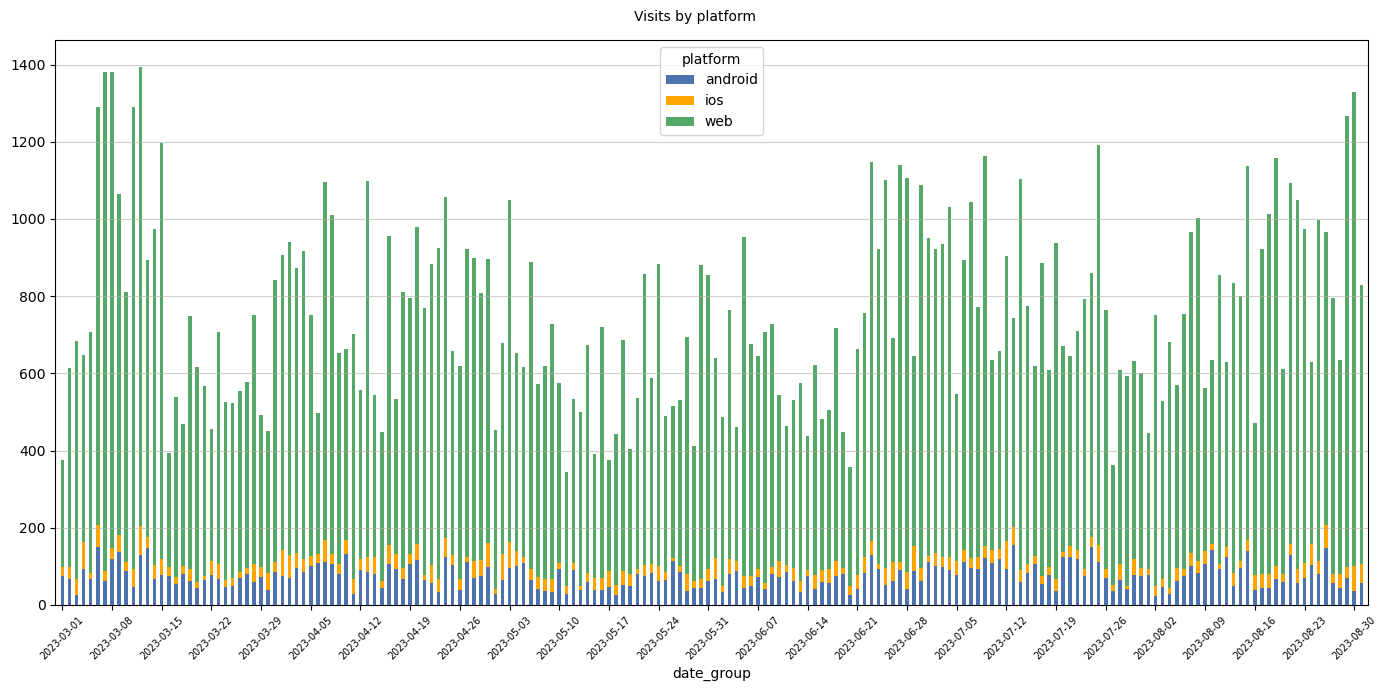

In [26]:
# график stacked bar Visits by platform
#Создаем pivot_table
pv_res3 = res3.pivot_table(values='visits', index='date_group', columns='platform', aggfunc='sum')
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Visits by platform",fontsize=10)
pv_res3.index = pd.to_datetime(pv_res3.index)
pv_res3.index = pv_res3.index.date
pv_res3.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0','#FFA500','#55A868'])
# 3. Настройки отображения
total_days = len(pv_res3.index)
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_xlim(-1,total_days)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=0))
plt.tight_layout()
plt.savefig('./charts/visits_by_platform.png')
plt.show()
plt.close()

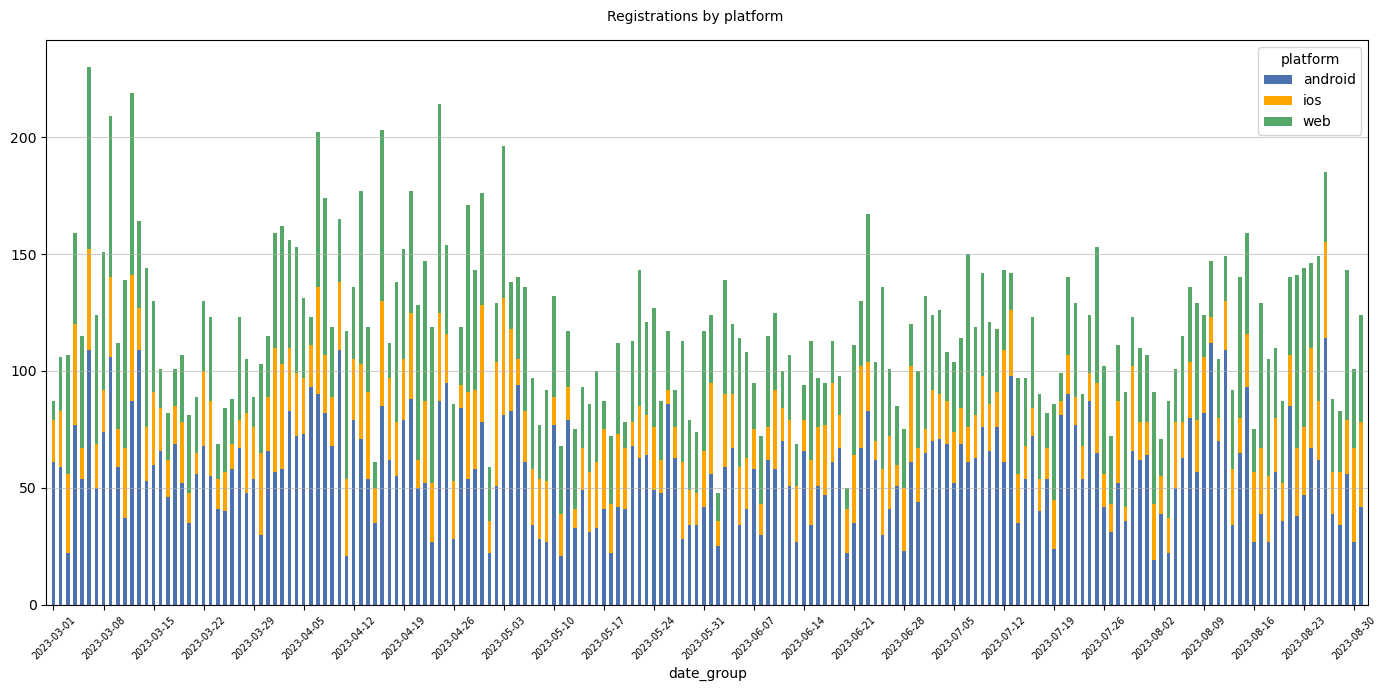

In [27]:
# график stacked bar registrations by platform
#Создаем pivot_table
pv_res3 = res3.pivot_table(values='registrations', index='date_group', columns='platform', aggfunc='sum')
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Registrations by platform",fontsize=10)
pv_res3.index = pd.to_datetime(pv_res3.index)
pv_res3.index = pv_res3.index.date
pv_res3.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0','#FFA500','#55A868'])
# 3. Настройки отображения
total_days = len(pv_res3.index)
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_xlim(-1,total_days)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=0))
plt.tight_layout()
plt.savefig('./charts/registrations_by_platform.png')
plt.show()
plt.close()

In [28]:
# для графика Aggregated Ad Aggregated Ad Campaign Costs Costs(by day)
# по новому группируем costs для графика Aggregated Ad Campaign Costs
df_agg_campaign = res6.groupby('date_group').agg(
cost=('cost', 'sum')
).reset_index()
res7 = df_agg_campaign
res7['cost'] = res7['cost'].astype('Int64')
print(res7.head())

   date_group  cost
0  2023-03-01   212
1  2023-03-02   252
2  2023-03-03   202
3  2023-03-04   223
4  2023-03-05   265


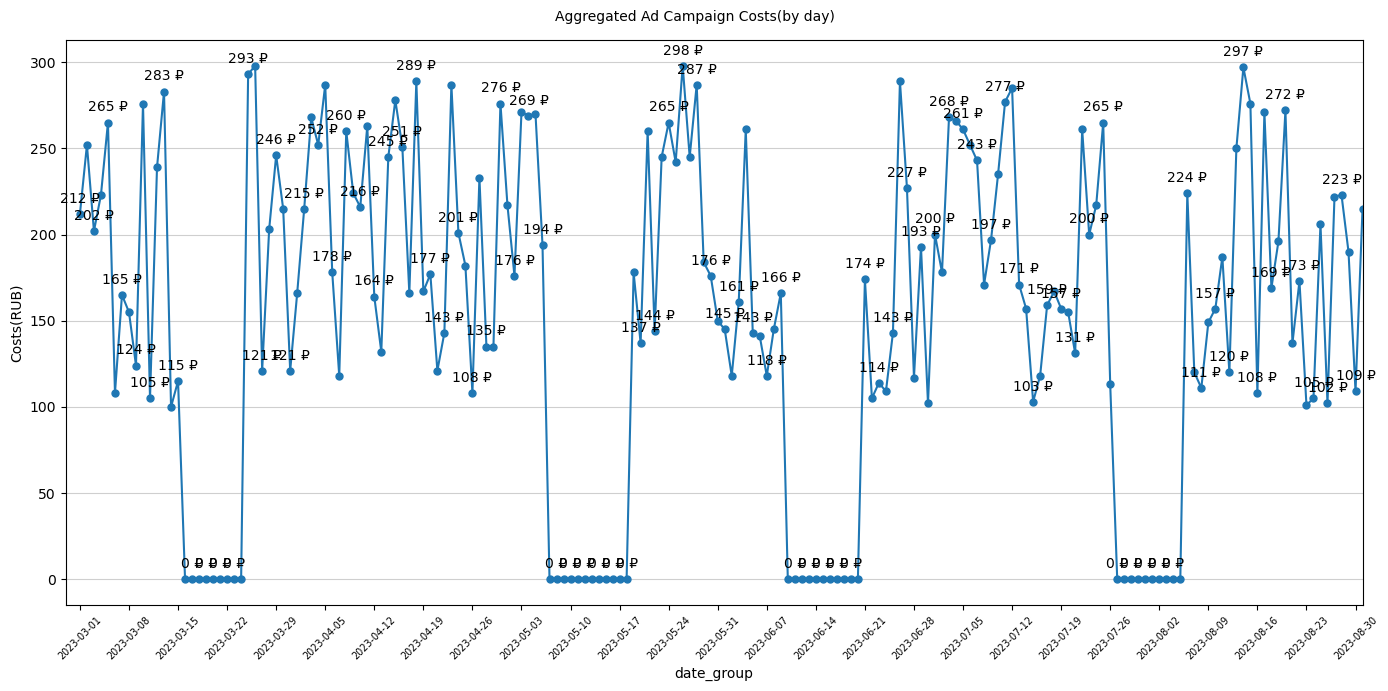

In [29]:
# график  Aggregated Ad Campaign Costs(by day)
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Aggregated Ad Campaign Costs(by day)",fontsize=10)
ax.plot(res7['date_group'], res7['cost'],marker='o',markersize=5)
for x, y in islice(zip(res7['date_group'], res7['cost']), 0, None, 2):
    # Форматируем текст: разделяем тысячи пробелом и добавляем '₽'
    label = f'{y:,.0f} ₽'.replace(',', ' ')
    
    plt.annotate(
        label,                     # Текст метки
        (x, y),                    # Координаты узла (x, y)
        textcoords="offset points",# Система смещения
        xytext=(0, 8),            # Смещение вверх на 10 пикселей
        ha='center',               # Выравнивание текста по центру
#        fontsize=10,               # Размер шрифта
#        color='darkgreen'          # Цвет текста
    )
# 3. Настройки отображения
total_days = len(res7['date_group'])
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_ylabel("Costs(RUB)")
#ax.xaxis.set_major_locator(MultipleLocator(7))
ax.set_xlim(res7['date_group'].iloc[0]-timedelta(days=2), res7['date_group'].iloc[total_days-1])
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
plt.tight_layout()
plt.savefig('./charts/aggregated_costs.png')
plt.show()
plt.close()

In [30]:
# для графика Overall Conversion
# по новому группируем conversion для графика
df_agg_conver = res5
df_agg_conver['conversion'] = ((df_agg_conver['registrations'] / df_agg_conver['visits']) * 100)
res8 = df_agg_conver
res8['conversion'] = res8['conversion'].astype('Int64')
print(res8.head())

   date_group  visits  registrations  conversion
0  2023-03-01     376             87          23
1  2023-03-02     613            106          17
2  2023-03-03     683            107          15
3  2023-03-04     647            159          24
4  2023-03-05     707            115          16


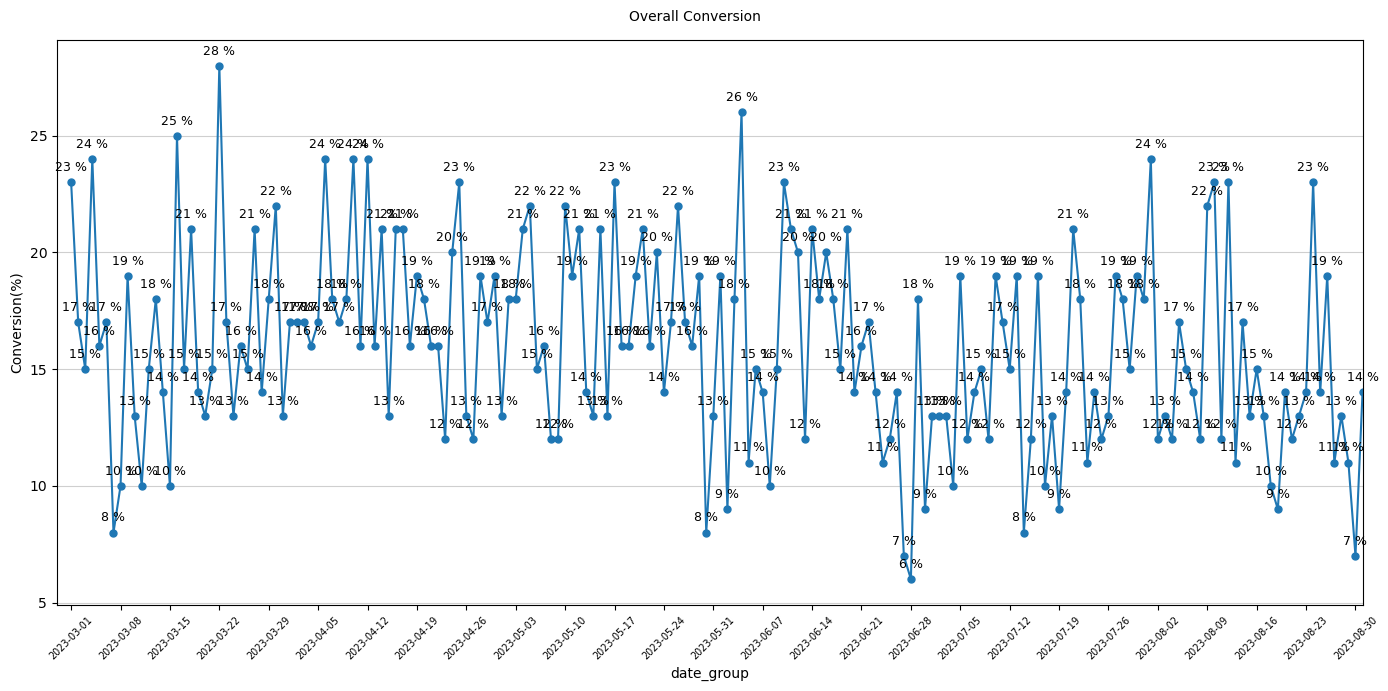

In [31]:
# график  Overall Conversion
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Overall Conversion",fontsize=10)
ax.plot(res8['date_group'], res8['conversion'],marker='o',markersize=5)
for x, y in islice(zip(res8['date_group'], res8['conversion']), 0, None, 1):
    # Форматируем текст: разделяем тысячи пробелом и добавляем '₽'
    label = f'{y:,.0f} %'.replace(',', ' ')
    
    plt.annotate(
        label,                     # Текст метки
        (x, y),                    # Координаты узла (x, y)
        textcoords="offset points",# Система смещения
        xytext=(0, 8),            # Смещение вверх на 10 пикселей
        ha='center',               # Выравнивание текста по центру
        fontsize=9,               # Размер шрифта
#        color='darkgreen'          # Цвет текста
    )
# 3. Настройки отображения
total_days = len(res8['date_group'])
ax.tick_params(axis='x',labelsize=7, labelrotation=45)
ax.grid(True,axis='y', alpha=0.6)
ax.set_xlabel("date_group",fontsize=10)
ax.set_ylabel("Conversion(%)")
#ax.xaxis.set_major_locator(MultipleLocator(7))
ax.set_xlim(res8['date_group'].iloc[0]-timedelta(days=2), res8['date_group'].iloc[total_days-1])
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')
plt.show()
plt.close()

In [32]:
#временно
res9 = res3[['date_group']] 
df_android= res3[res3['platform'] == 'android'].reset_index(drop=True)
df_ios = res3[res3['platform'] == 'ios'].reset_index(drop=True)
df_web = res3[res3['platform'] == 'web'].reset_index(drop=True)
print(res3.head())
print(df_ios.head())
#res3.to_csv('test_conver_by_platform290526v1.csv')

   date_group platform  visits  registrations  conversion
0  2023-03-01  android      75             61          81
1  2023-03-01      ios      22             18          81
2  2023-03-01      web     279              8           2
3  2023-03-02  android      67             59          88
4  2023-03-02      ios      31             24          77
   date_group platform  visits  registrations  conversion
0  2023-03-01      ios      22             18          81
1  2023-03-02      ios      31             24          77
2  2023-03-03      ios      40             34          85
3  2023-03-04      ios      68             43          63
4  2023-03-05      ios      16             13          81


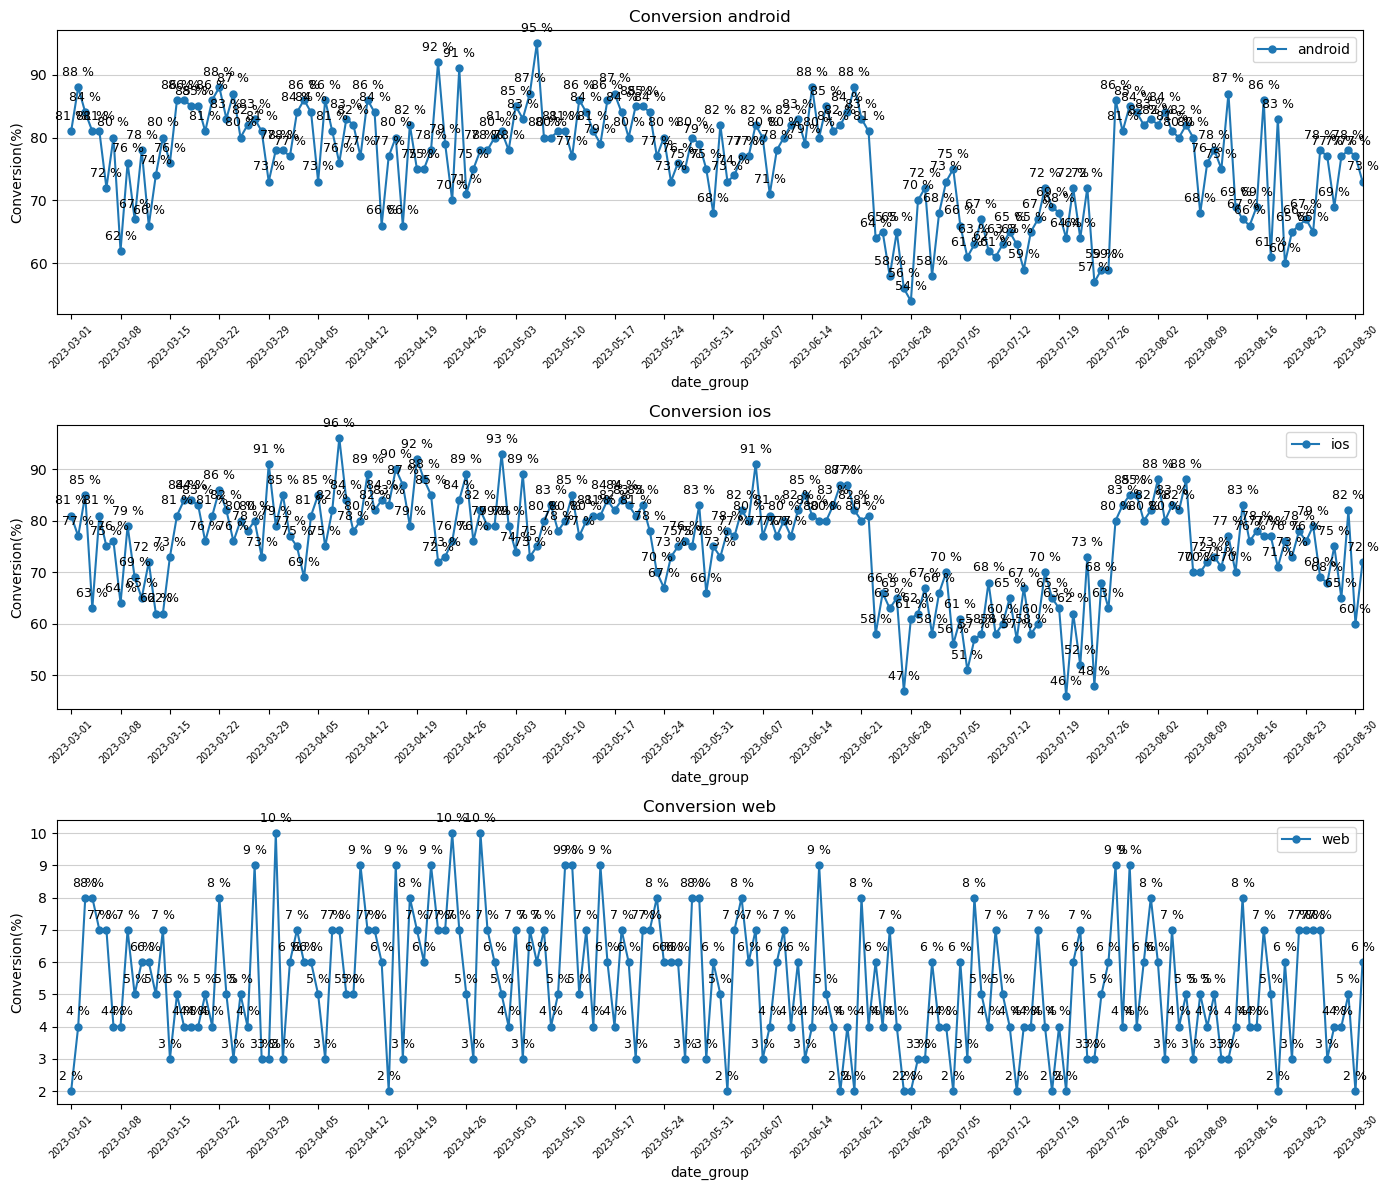

In [33]:
# график Conversion_by_platform
# необходимые датафреймы
df_android = res3[res3['platform'] == 'android'].reset_index(drop=True)
df_ios = res3[res3['platform'] == 'ios'].reset_index(drop=True)
df_web = res3[res3['platform'] == 'web'].reset_index(drop=True)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(14, 12))
#fig.suptitle("Overall Conversion",fontsize=10)
# 3. Построение графиков на каждой отдельной оси
ax1.plot(df_ios['date_group'], df_android['conversion'],label='android',marker='o',markersize=5)
ax2.plot(df_ios['date_group'], df_ios['conversion'],label='ios',marker='o',markersize=5)
ax3.plot(df_ios['date_group'], df_web['conversion'],label='web',marker='o',markersize=5)

# AX1
for x, y in islice(zip(df_ios['date_group'], df_android['conversion']), 0, None, 1):
    # Форматируем текст: разделяем тысячи пробелом и добавляем '₽'
    label = f'{y:,.0f} %'.replace(',', ' ')    
    ax1.annotate(
        label,                     # Текст метки
        (x, y),                    # Координаты узла (x, y)
        textcoords="offset points",# Система смещения
        xytext=(0, 8),            # Смещение вверх на 10 пикселей
        ha='center',               # Выравнивание текста по центру
        fontsize=9,               # Размер шрифта
#        color='darkgreen'          # Цвет текста
    )
# AX1 Настройки отображения
ax1.set_title('Conversion android',fontsize=12)
total_days = len(df_ios['date_group'])
ax1.tick_params(axis='x',labelsize=7, labelrotation=45)
ax1.grid(True,axis='y', alpha=0.6)
ax1.set_xlabel("date_group",fontsize=10)
ax1.set_ylabel("Conversion(%)")
ax1.set_xlim(df_ios['date_group'].iloc[0]-timedelta(days=2), df_ios['date_group'].iloc[total_days-1])
ax1.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
#mean_andr = df_android['conversion'].mean().round(0)
#ax1.axhline(y=mean_andr, linestyle='--', label=f'AOV: {mean_andr}')
ax1.legend()
# AX2
for x, y in islice(zip(df_ios['date_group'],df_ios['conversion']), 0, None, 1):
    # Форматируем текст: разделяем тысячи пробелом и добавляем '₽'
    label = f'{y:,.0f} %'.replace(',', ' ')    
    ax2.annotate(
        label,                     # Текст метки
        (x, y),                    # Координаты узла (x, y)
        textcoords="offset points",# Система смещения
        xytext=(0, 8),            # Смещение вверх на 10 пикселей
        ha='center',               # Выравнивание текста по центру
        fontsize=9,               # Размер шрифта
#        color='darkgreen'          # Цвет текста
    )
# AX2 Настройки отображения
ax2.set_title('Conversion ios',fontsize=12)
#total_days = len(df_ios['date_group'])
ax2.tick_params(axis='x',labelsize=7, labelrotation=45)
ax2.grid(True,axis='y', alpha=0.6)
ax2.set_xlabel("date_group",fontsize=10)
ax2.set_ylabel("Conversion(%)")
ax2.set_xlim(df_ios['date_group'].iloc[0]-timedelta(days=2), df_ios['date_group'].iloc[total_days-1])
ax2.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
ax2.legend()
# AX3
for x, y in islice(zip(df_ios['date_group'],df_web['conversion']), 0, None, 1):
    # Форматируем текст: разделяем тысячи пробелом и добавляем '₽'
    label = f'{y:,.0f} %'.replace(',', ' ')    
    ax3.annotate(
        label,                     # Текст метки
        (x, y),                    # Координаты узла (x, y)
        textcoords="offset points",# Система смещения
        xytext=(0, 8),            # Смещение вверх на 10 пикселей
        ha='center',               # Выравнивание текста по центру
        fontsize=9,               # Размер шрифта
#        color='darkgreen'          # Цвет текста
    )
# AX3 Настройки отображения
ax3.set_title('Conversion web',fontsize=12)
#total_days = len(df_ios['date_group'])
ax3.tick_params(axis='x',labelsize=7, labelrotation=45)
ax3.grid(True,axis='y', alpha=0.6)
ax3.set_xlabel("date_group",fontsize=10)
ax3.set_ylabel("Conversion(%)")
ax3.set_xlim(df_ios['date_group'].iloc[0]-timedelta(days=2), df_ios['date_group'].iloc[total_days-1])
ax3.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
ax3.legend()

plt.tight_layout()
#plt.savefig('./charts/conversion_by_platform.png')
plt.show()
plt.close()
#print(df_ios.head())

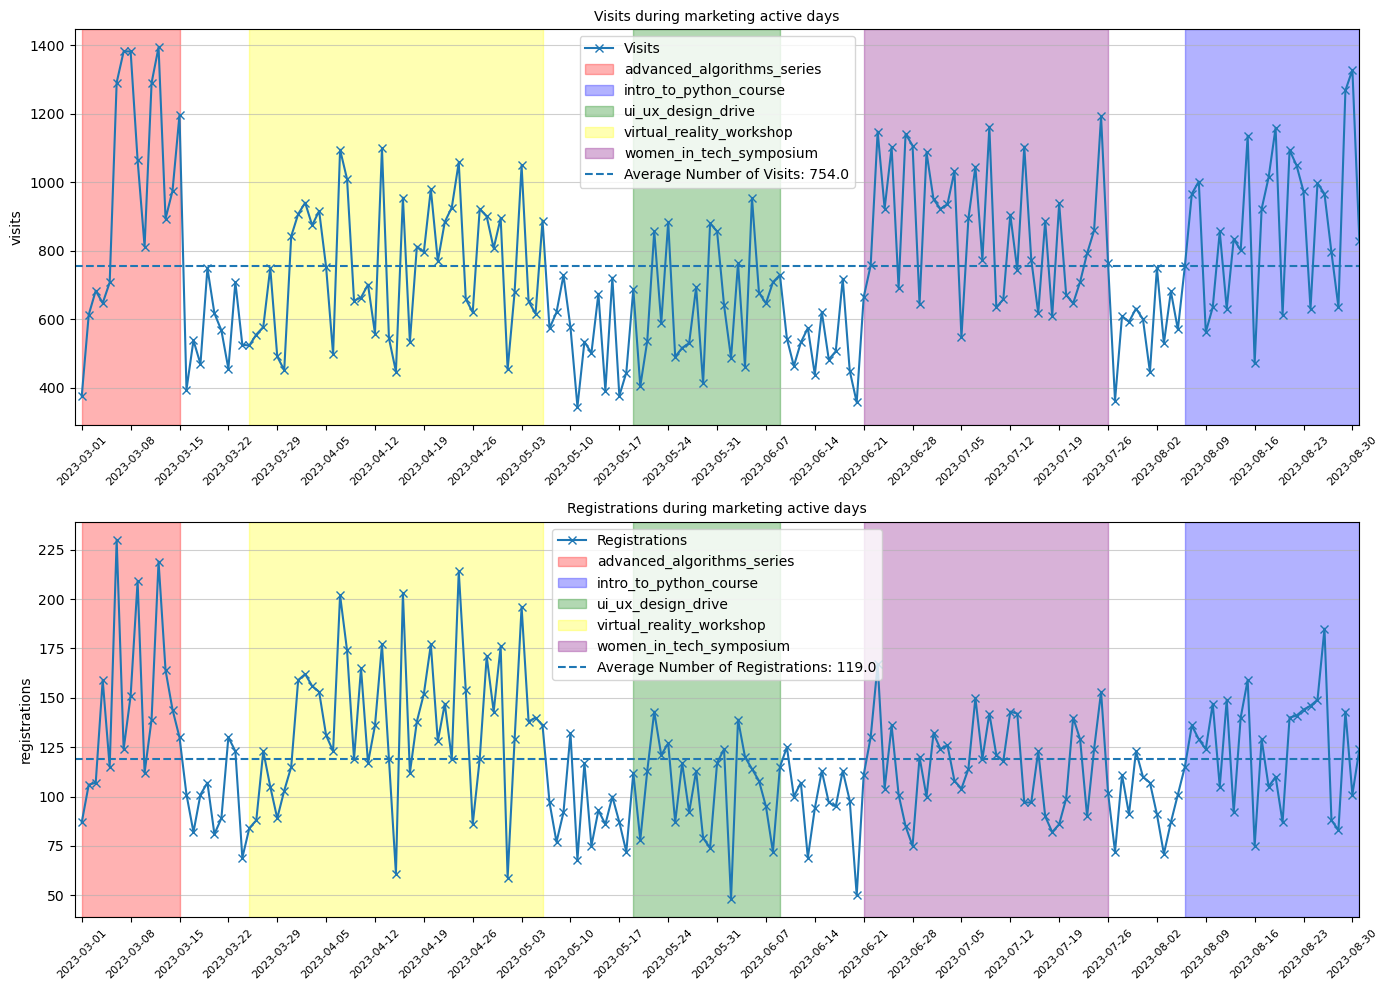

In [34]:
#график vis_and_reg_during_marketing_active_days
#res6['date_group'] = pd.to_datetime(res6['date_group'])
sort6 = res6.sort_values(by=['utm_campaign', 'date_group'])
inter = sort6.groupby('utm_campaign')['date_group'].agg(
    start_date='first',
    end_date='last'
).reset_index()
colors = ['red', 'blue', 'green', 'yellow', 'purple']
inter['color'] = colors

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))
#fig.suptitle("Visits during marketing active days",fontsize=10)
# 3. Построение графиков на каждой отдельной оси
ax1.plot(res6['date_group'], res6['visits'], marker='x',label='Visits')
ax2.plot(res6['date_group'], res6['registrations'], marker='x',label='Registrations')
started = inter['start_date'].to_list()
ended = inter['end_date'].to_list()
# ax1
for i in range(len(started)):
    ax1.axvspan(started[i], ended[i], alpha=0.3, color=inter['color'].to_list()[i] , label=inter['utm_campaign'].to_list()[i] )
mean_visit = res6['visits'].mean().round(0)
ax1.axhline(y=mean_visit, linestyle='--', label=f'Average Number of Visits: {mean_visit}')
# ax1 Настройки отображения
ax1.set_title("Visits during marketing active days",fontsize=10)
total_days = len(res6['date_group'])
ax1.set_xlim(res6['date_group'].iloc[0]-timedelta(days=1), res6['date_group'].iloc[total_days-1]) # 
ax1.tick_params(axis='x',labelsize=8, labelrotation=45)
ax1.grid(True,axis='y', alpha=0.6)
ax1.set_ylabel("visits")
ax1.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
ax1.legend()
# ax2
for i in range(len(started)):
    ax2.axvspan(started[i], ended[i], alpha=0.3, color=inter['color'].to_list()[i] , label=inter['utm_campaign'].to_list()[i] )
mean_reg = res6['registrations'].mean().round(0)
ax2.axhline(y=mean_reg, linestyle='--', label=f'Average Number of Registrations: {mean_reg}')
# ax2 Настройки отображения
ax2.set_title('Registrations during marketing active days',fontsize=10)
total_days = len(res6['date_group'])
ax2.set_xlim(res6['date_group'].iloc[0]-timedelta(days=1), res6['date_group'].iloc[total_days-1]) # 
ax2.tick_params(axis='x',labelsize=8, labelrotation=45)
ax2.grid(True,axis='y', alpha=0.6)
ax2.set_ylabel("registrations")
ax2.xaxis.set_major_locator(ticker.MultipleLocator(base=7, offset=-1))
ax2.legend()
#plt.legend()
plt.tight_layout()
plt.savefig('./charts/vis_and_reg_during_marketing_active_days.png')
plt.show()
plt.close()